# True parameters at 1 PA model
```python
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5 
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5
best_fit_0pa_vs_1pa =  [13.81555957,10.00042571,0.80004275,7.49978425,0.39998768,0.78295617,1.00614064,0.96784745,0.35215207]
best_fit_with_deviation =  = [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]

```

In [1]:
from itertools import product
import os
import h5py
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass 

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np
best_fit_0pa_vs_1pa =  [13.81555957,10.00042571,0.80004275,7.49978425,0.39998768,0.78295617,1.00614064,0.96784745,0.35215207]
best_fit_with_deviation = [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5 
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e,]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

emri_kwargs = {"T":T, "dt":dt}
der_order = 8
Ndelta=16


# Fisher at Best FIT 0PA With Deviation

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000119.1991393781), 10.00108591, 0.80008239, 7.49955089, 0.39996359, 1.0, 0.5, 0.7889396, 1.00931468, 1, 1.0471975511965976, 0.97747737, 0.5, 0.35608951, 0.9, False, False, False, True, 1.26255293, -1.44475749)
SNR:  109.56288335761433
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000119.1991393781), 10.00108591, 0.80008239, 7.49955089, 0.39996359, 1.0, 0.5, 0.7889396, 1.00931468, 1, 1.0471975511965976, 0.97747737, 0.5, 0.35608951, 0.9, False, False, False, True, 1.26255293, -1.44475749)
Waveform Generated. SNR: 109.56288335761433
calculating stable deltas...
Gamma_ii for m1: 14256.79564139614
Gamma_ii for m1: 14256.795730430635
Gamma_ii for m1: 14256.795599127123
Gamma_ii for m1: 14256.794463539321
Gamma_ii for m1: 14256.796248501678
Gamma_ii for m1: 14256.797578340087
Gamma_ii for m1: 14256.803667136177
Gamma_ii for

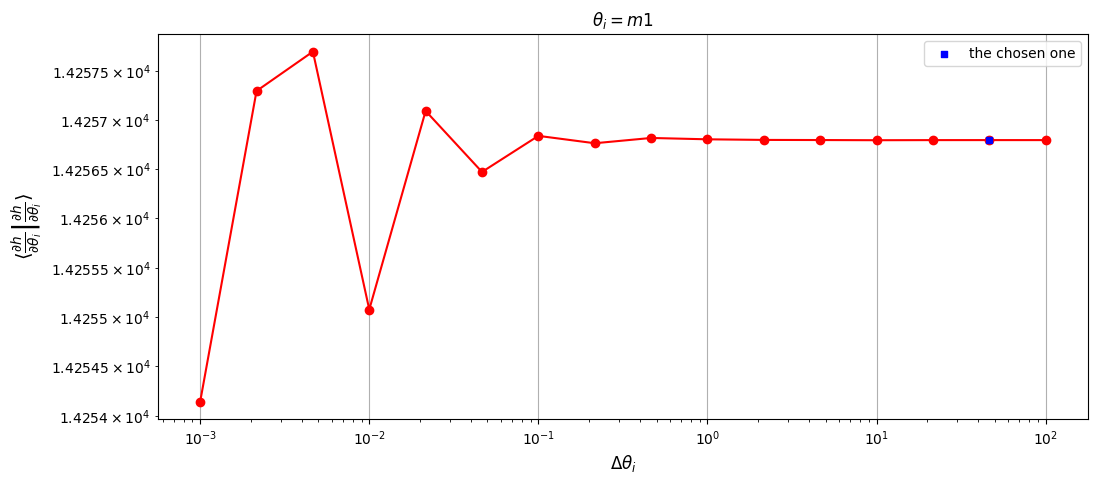

Gamma_ii for m2: 9091416940165.021
Gamma_ii for m2: 9091417338003.768
Gamma_ii for m2: 9091416938927.96
Gamma_ii for m2: 9091416824306.816
Gamma_ii for m2: 9091419028127.744
Gamma_ii for m2: 9091408725008.484
Gamma_ii for m2: 9091409160520.582
Gamma_ii for m2: 9091404111107.363
Gamma_ii for m2: 9091460748930.723
Gamma_ii for m2: 9091361732669.146
Gamma_ii for m2: 9091196270395.248
Gamma_ii for m2: 9091656483035.604
Gamma_ii for m2: 9087115767887.354
Gamma_ii for m2: 9093311456156.514
Gamma_ii for m2: 9093551556639.006
Gamma_ii for m2: 9085427546260.615
[np.float64(4.375981558240783e-08), np.float64(4.389588656217576e-08), np.float64(1.2607621754268142e-08), np.float64(2.4240670470869523e-07), np.float64(1.1332808337418588e-06), np.float64(4.7903695672114286e-08), np.float64(5.554052110147554e-07), np.float64(6.229782531485533e-06), np.float64(1.0891246491750972e-05), np.float64(1.820027518680376e-05), np.float64(5.061922887365943e-05), np.float64(0.0004996871685399099), np.float64(0.00

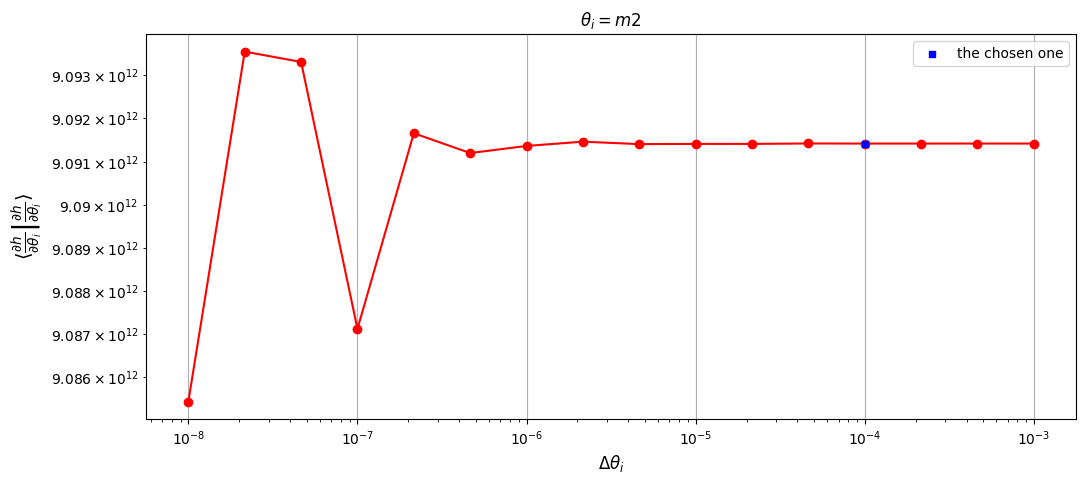

Gamma_ii for a: 1163819013390841.0
Gamma_ii for a: 1163819027468940.5
Gamma_ii for a: 1163819142348205.0
Gamma_ii for a: 1163818775087889.5
Gamma_ii for a: 1163820046074996.8
Gamma_ii for a: 1163819086937874.5
Gamma_ii for a: 1163818707599091.0
Gamma_ii for a: 1163813281375314.5
Gamma_ii for a: 1163812423257411.5
Gamma_ii for a: 1163835865613497.0
Gamma_ii for a: 1163787008924827.5
Gamma_ii for a: 1163776718707737.8
Gamma_ii for a: 1163979106579474.5
Gamma_ii for a: 1162907586397217.8
Gamma_ii for a: 1161856307121352.2
Gamma_ii for a: 1159275182786524.8
[np.float64(1.209646789382442e-08), np.float64(9.870886319004115e-08), np.float64(3.1556486573458585e-07), np.float64(1.0920821578356775e-06), np.float64(8.241290532307616e-07), np.float64(3.2594319117155276e-07), np.float64(4.6624521848450314e-06), np.float64(7.373335134180827e-07), np.float64(2.014232142016241e-05), np.float64(4.198078195995381e-05), np.float64(8.842088799624981e-06), np.float64(0.0001738758630569382), np.float64(0.00

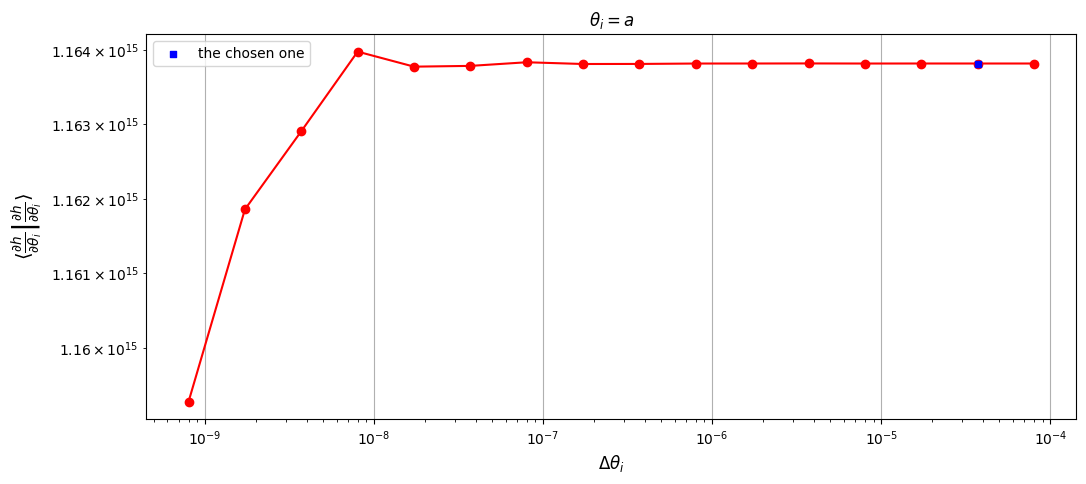

Gamma_ii for p0: 751739217117730.6
Gamma_ii for p0: 751739224355194.9
Gamma_ii for p0: 751739230996010.2
Gamma_ii for p0: 751739224442319.4
Gamma_ii for p0: 751739278414241.8
Gamma_ii for p0: 751739228726996.9
Gamma_ii for p0: 751739513590265.4
Gamma_ii for p0: 751739111001059.5
Gamma_ii for p0: 751739257513428.0
Gamma_ii for p0: 751737948417609.5
Gamma_ii for p0: 751733344018140.1
Gamma_ii for p0: 751745582311361.6
Gamma_ii for p0: 751706199834630.1
Gamma_ii for p0: 751786579873419.9
Gamma_ii for p0: 751726543549839.2
Gamma_ii for p0: 751838010625227.5
[np.float64(9.62762619737974e-09), np.float64(8.833934828971624e-09), np.float64(8.718037667732293e-09), np.float64(7.179606537103024e-08), np.float64(6.609638419314753e-08), np.float64(3.7893879907883136e-07), np.float64(5.355437810584164e-07), np.float64(1.9489785458940584e-07), np.float64(1.7414257471710927e-06), np.float64(6.125043549037903e-06), np.float64(1.627983390852982e-05), np.float64(5.239078344726152e-05), np.float64(0.0001

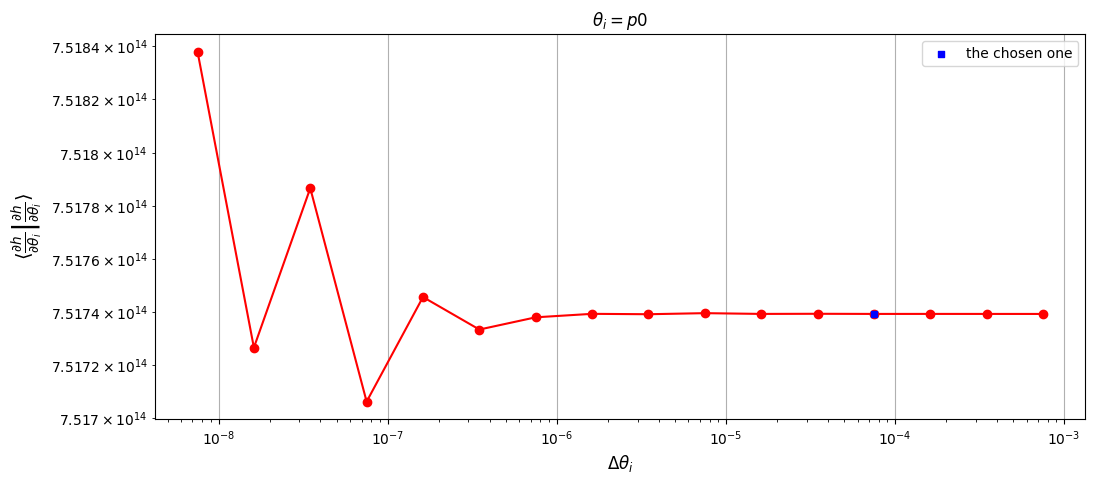

Gamma_ii for e0: 2445914114021751.5
Gamma_ii for e0: 2445914073232487.5
Gamma_ii for e0: 2445914322877841.5
Gamma_ii for e0: 2445913944286412.0
Gamma_ii for e0: 2445913187531774.5
Gamma_ii for e0: 2445911684332211.0
Gamma_ii for e0: 2445908063562413.5
Gamma_ii for e0: 2445910862650228.0
Gamma_ii for e0: 2445885654522764.5
Gamma_ii for e0: 2445871222924774.5
Gamma_ii for e0: 2445860455688569.0
Gamma_ii for e0: 2446141091949064.5
Gamma_ii for e0: 2444817746655944.0
Gamma_ii for e0: 2444083759207967.5
Gamma_ii for e0: 2458561480927405.0
Gamma_ii for e0: 2450103406867104.5
[np.float64(1.6676490988129215e-08), np.float64(1.0206627095027166e-07), np.float64(1.547852615110925e-07), np.float64(3.093955424737122e-07), np.float64(6.145763860277757e-07), np.float64(1.4803376510507207e-06), np.float64(1.1443948580640804e-06), np.float64(1.0306339307762345e-05), np.float64(5.900391588377529e-06), np.float64(4.402228336640228e-06), np.float64(0.0001147261134769178), np.float64(0.0005412858667811089)

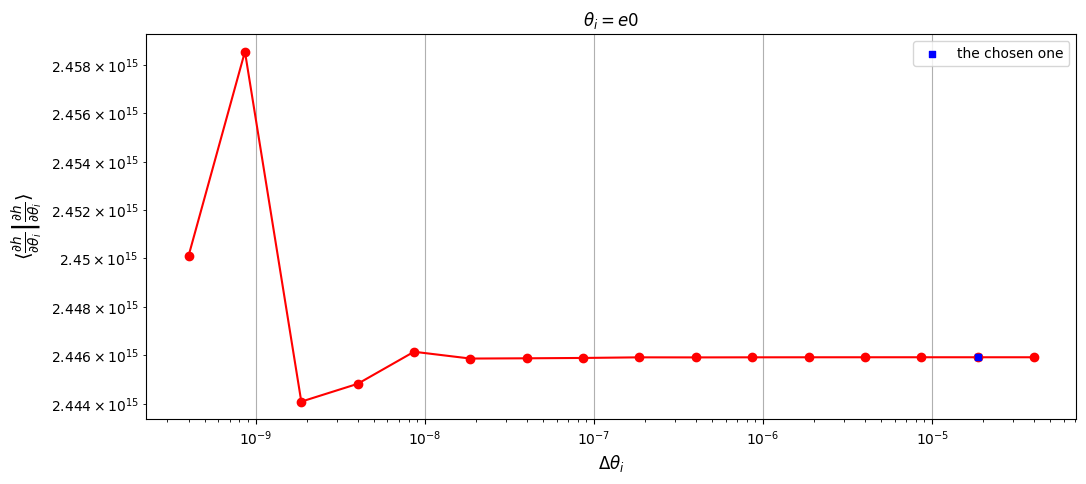

Gamma_ii for qS: 26950.2538177515
Gamma_ii for qS: 26950.25388114796
Gamma_ii for qS: 26950.253881287248
Gamma_ii for qS: 26950.25388128742
Gamma_ii for qS: 26950.253881286935
Gamma_ii for qS: 26950.253881288405
Gamma_ii for qS: 26950.253881286506
Gamma_ii for qS: 26950.253881280878
Gamma_ii for qS: 26950.253881283457
Gamma_ii for qS: 26950.253881301793
Gamma_ii for qS: 26950.253881276425
Gamma_ii for qS: 26950.25388111825
Gamma_ii for qS: 26950.25388129354
Gamma_ii for qS: 26950.253881559936
Gamma_ii for qS: 26950.253880873843
Gamma_ii for qS: 26950.253881251534
[np.float64(2.3523510922717367e-09), np.float64(5.168311037093188e-12), np.float64(6.344467279843767e-15), np.float64(1.7953492515302896e-14), np.float64(5.453542087354868e-14), np.float64(7.046408340592678e-14), np.float64(2.0882746557278062e-13), np.float64(9.570696385978493e-14), np.float64(6.803428742637347e-13), np.float64(9.412759647312475e-13), np.float64(5.86917218855444e-12), np.float64(6.5042938598281405e-12), np.flo

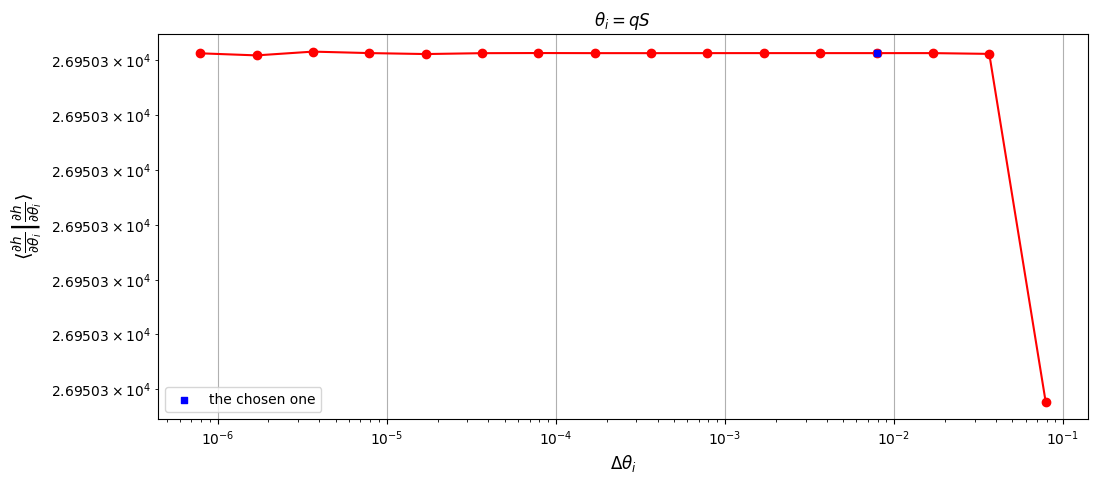

Gamma_ii for phiS: 747746.5633838084
Gamma_ii for phiS: 747746.5633622283
Gamma_ii for phiS: 747746.5633621806
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621806
Gamma_ii for phiS: 747746.563362181
Gamma_ii for phiS: 747746.5633621819
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621797
Gamma_ii for phiS: 747746.5633621721
Gamma_ii for phiS: 747746.5633621885
Gamma_ii for phiS: 747746.5633622457
[np.float64(2.8860078641279955e-11), np.float64(6.383216491751966e-14), np.float64(1.5568820711590163e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.556882071159016e-16), np.float64(4.670646213477046e-16), np.float64(1.2455056569272107e-15), np.float64(1.8682584853908194e-15), np.float64(1.0898174498113126e-15), np.float64(1.011973346253372e-14), np.float64(2.1952037

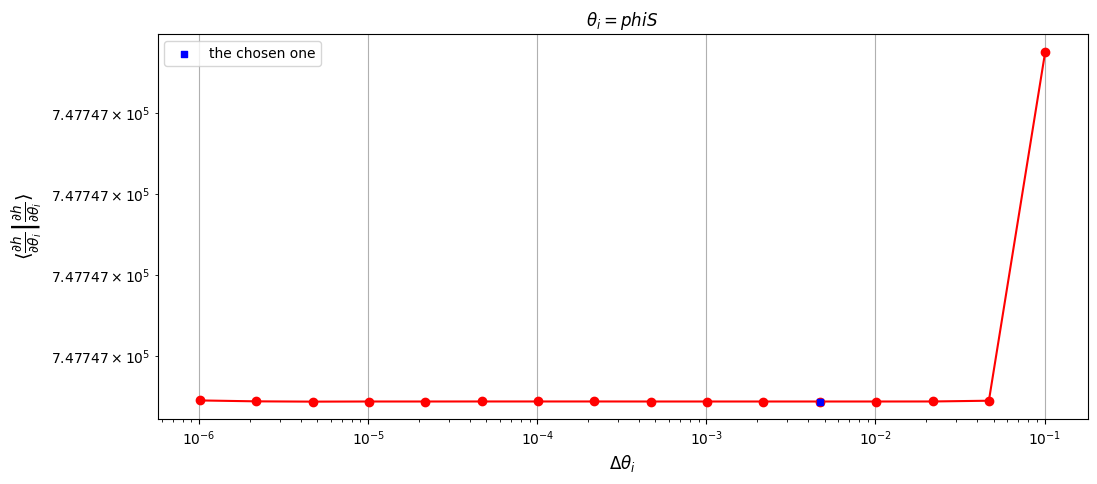

Gamma_ii for devCp: 5004.455417647473
Gamma_ii for devCp: 5004.406564818338
Gamma_ii for devCp: 5004.477811347297
Gamma_ii for devCp: 5004.107929037392
Gamma_ii for devCp: 5004.302827509156
Gamma_ii for devCp: 5002.134685273562
Gamma_ii for devCp: 5000.17426044017
Gamma_ii for devCp: 5007.615983918248
Gamma_ii for devCp: 4989.163111872262
Gamma_ii for devCp: 5007.49785385537
Gamma_ii for devCp: 4966.910037830269
Gamma_ii for devCp: 4573.215968297503
Gamma_ii for devCp: 5323.363387926623
Gamma_ii for devCp: 5555.101126763394
Gamma_ii for devCp: 3346.817477468054
Gamma_ii for devCp: 8021.640702096309
[np.float64(9.761962482969921e-06), np.float64(1.4236556069319084e-05), np.float64(7.391573386307357e-05), np.float64(3.894617861500295e-05), np.float64(0.0004334433940725946), np.float64(0.0003920713021749826), np.float64(0.0014860811016614126), np.float64(0.003698590651822144), np.float64(0.0036614577815528545), np.float64(0.008171643077077092), np.float64(0.0860869183222345), np.float64(0

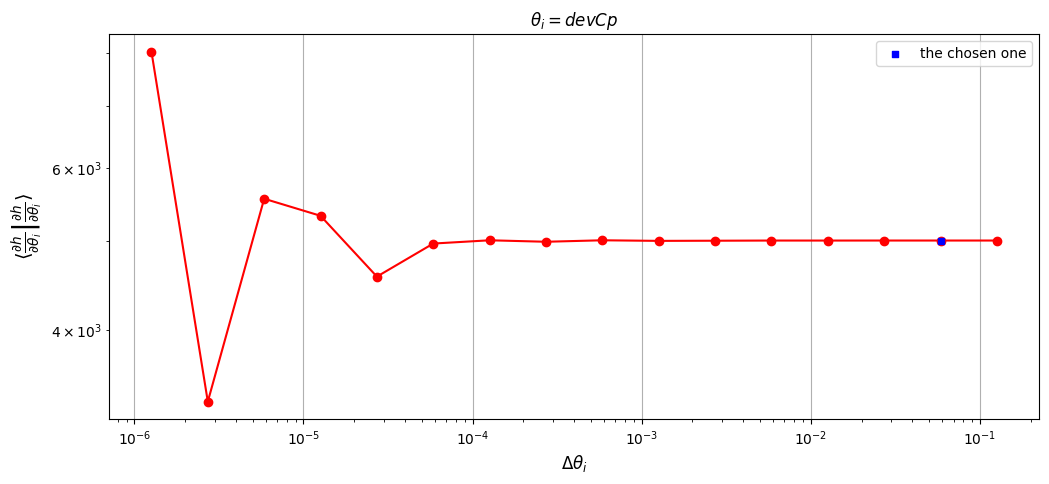

Gamma_ii for devCe: 32695.257307836328
Gamma_ii for devCe: 32695.22591527205
Gamma_ii for devCe: 32695.803672289865
Gamma_ii for devCe: 32695.52742314476
Gamma_ii for devCe: 32693.36995051081
Gamma_ii for devCe: 32694.678320676314
Gamma_ii for devCe: 32704.666298059063
Gamma_ii for devCe: 32692.63753122103
Gamma_ii for devCe: 32761.899325406517
Gamma_ii for devCe: 32604.178759963106
Gamma_ii for devCe: 32619.998818544784
Gamma_ii for devCe: 32262.079014268482
Gamma_ii for devCe: 31693.595179957087
Gamma_ii for devCe: 33358.95688229618
Gamma_ii for devCe: 21150.07155040109
Gamma_ii for devCe: 35917.850512669844
[np.float64(9.601574357708785e-07), np.float64(1.767067797461572e-05), np.float64(8.449141729126846e-06), np.float64(6.599113634401587e-05), np.float64(4.00178326476336e-05), np.float64(0.0003053991528830109), np.float64(0.0003679350381732286), np.float64(0.002114095812869311), np.float64(0.004837434078759465), np.float64(0.00048498035422011514), np.float64(0.01109413327386637), 

/home/svu/e1583490/scratch/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


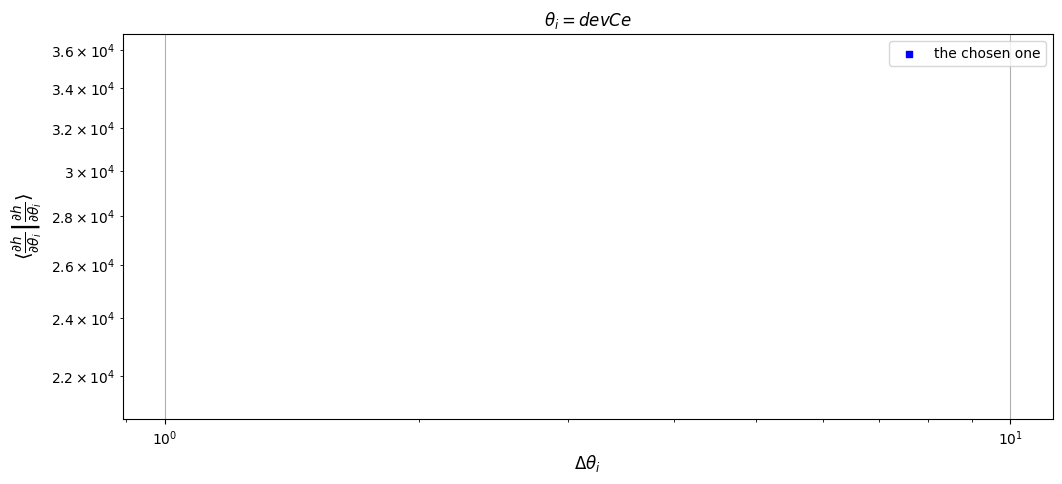

stable deltas: {'m1': 46.42142107007095, 'm2': 0.00010001085909999995, 'a': 3.713653487394226e-05, 'p0': 7.49955089000001e-05, 'e0': 1.8564665331956806e-05, 'qS': 0.007889395999999996, 'phiS': 0.004684823748289457, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devCp': 0.05860251581733096, 'devCe': -0.06705970232862428}
Time taken to compute stable deltas is 314.9036214351654 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 21.11376953125 seconds


In [4]:
logm1_bf = best_fit_with_deviation[0]
m1_bf = np.exp(logm1_bf)
m2_bf = best_fit_with_deviation[1]
a_bf = best_fit_with_deviation[2]
p0_bf = best_fit_with_deviation[3]
e0_bf  = best_fit_with_deviation[4]
qS_bf = best_fit_with_deviation[5]
phiS_bf = best_fit_with_deviation[6]
Phi_phi0_bf = best_fit_with_deviation[7]
Phi_r0_bf = best_fit_with_deviation[8]
dev_Cp_bf =best_fit_with_deviation[9]
dev_Ce_bf =best_fit_with_deviation[10]

evolve_1PA_bf = False
deviation_included_bf = True

pars_list_com = [m1_bf, m2_bf, a_bf, p0_bf, e0_bf, xI0, dist, qS_bf, phiS_bf, qK, phiK, Phi_phi0_bf, Phi_theta0, Phi_r0_bf,\
             chi2,evolve_1PA_bf,evolve_primary,evolve_2PA,deviation_included_bf,dev_Cp_bf,dev_Ce_bf]

add_param_args_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_bf,"devCp":dev_Cp_bf,"devCe":dev_Ce_bf}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devCp','devCe']

add_args_bf = [chi2, evolve_1PA_bf, evolve_primary, evolve_2PA,deviation_included_bf,dev_Cp_bf,dev_Ce_bf]

sef_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_bf = {
    'm1': m1_bf,
    'm2': m2_bf,
    'a': a_bf,
    'p0': p0_bf,
    'e0': e0_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_bf,
    'phiS': phiS_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_bf
}


Fisher_bf = sef_bf(wave_params = param_dict_bf,param_names=param_names, add_param_args=add_param_args_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

# Fisher Best FIT Point 0PA without Deviation


waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000049.0132368349), 10.00042571, 0.80004275, 7.49978425, 0.39998768, 1.0, 0.5, 0.78295617, 1.00614064, 1, 1.0471975511965976, 0.96784745, 0.5, 0.35215207, 0.9, False, False, False, True, 0, 0, 0)
SNR:  109.40919820003411
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000049.0132368349), 10.00042571, 0.80004275, 7.49978425, 0.39998768, 1.0, 0.5, 0.78295617, 1.00614064, 1, 1.0471975511965976, 0.96784745, 0.5, 0.35215207, 0.9, False, False, False, True, 0, 0)
Waveform Generated. SNR: 109.40919820003411
calculating stable deltas...
Gamma_ii for m1: 14229.541923632272
Gamma_ii for m1: 14229.541923332941
Gamma_ii for m1: 14229.5419233711
Gamma_ii for m1: 14229.541923028184
Gamma_ii for m1: 14229.541923647463
Gamma_ii for m1: 14229.541922269305
Gamma_ii for m1: 14229.54192141573
Gamma_ii for m1: 14229.541930573178
Gamma_ii fo

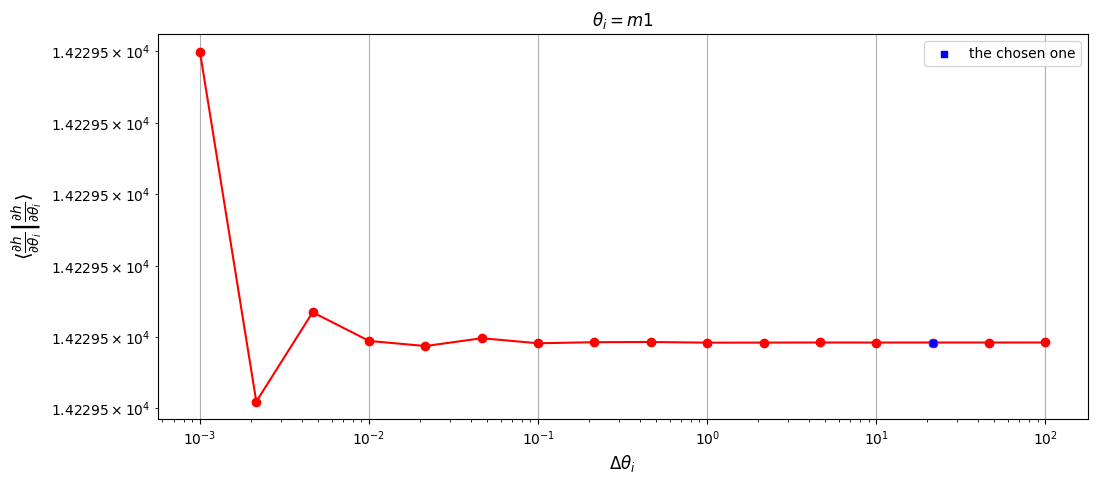

Gamma_ii for m2: 9073503160735.47
Gamma_ii for m2: 9073503160386.574
Gamma_ii for m2: 9073503160320.81
Gamma_ii for m2: 9073503160390.004
Gamma_ii for m2: 9073503161102.664
Gamma_ii for m2: 9073503163533.121
Gamma_ii for m2: 9073503158629.152
Gamma_ii for m2: 9073503144296.691
Gamma_ii for m2: 9073503177600.494
Gamma_ii for m2: 9073503267380.809
Gamma_ii for m2: 9073503160135.713
Gamma_ii for m2: 9073502984662.73
Gamma_ii for m2: 9073503056505.947
Gamma_ii for m2: 9073502150887.58
Gamma_ii for m2: 9073503354786.117
Gamma_ii for m2: 9073501119867.002
[np.float64(3.8452235945453215e-11), np.float64(7.2478810788968525e-12), np.float64(7.625870422028472e-12), np.float64(7.854299972089209e-11), np.float64(2.67863138133696e-10), np.float64(5.404713774013722e-10), np.float64(1.5795950813671033e-09), np.float64(3.670445921768251e-09), np.float64(9.894779536354465e-09), np.float64(1.1819590935318628e-08), np.float64(1.9339056009402688e-08), np.float64(7.917913990822042e-09), np.float64(9.980913

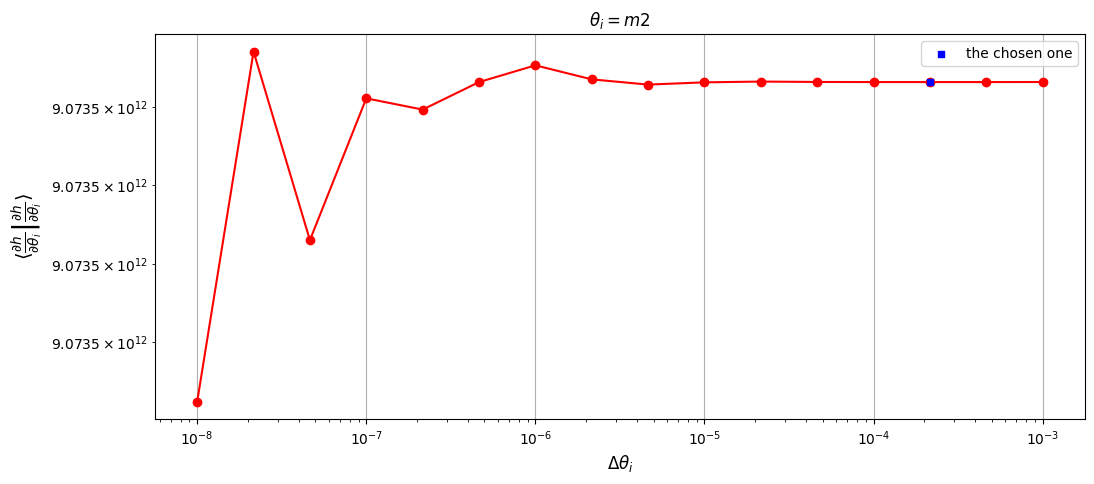

Gamma_ii for a: 1161295497224663.2
Gamma_ii for a: 1161295578270562.5
Gamma_ii for a: 1161295698729491.0
Gamma_ii for a: 1161295056862184.5
Gamma_ii for a: 1161295280691789.0
Gamma_ii for a: 1161294773741586.2
Gamma_ii for a: 1161292212467358.0
Gamma_ii for a: 1161290285754129.0
Gamma_ii for a: 1161332555324010.2
Gamma_ii for a: 1161315432910643.0
Gamma_ii for a: 1161414307868961.2
Gamma_ii for a: 1161501045277280.8
Gamma_ii for a: 1160659256504699.0
Gamma_ii for a: 1160349256390781.5
Gamma_ii for a: 1161483343885843.5
Gamma_ii for a: 1169438961102560.5
[np.float64(6.978920850684377e-08), np.float64(1.0372804155891338e-07), np.float64(5.52716816202011e-07), np.float64(1.9274133652438824e-07), np.float64(4.3653877913929857e-07), np.float64(2.205538107250498e-06), np.float64(1.659114222030036e-06), np.float64(3.6397472616667364e-05), np.float64(1.474398159364466e-05), np.float64(8.513323595924371e-05), np.float64(7.467699548974018e-05), np.float64(0.0007252677888571528), np.float64(0.000

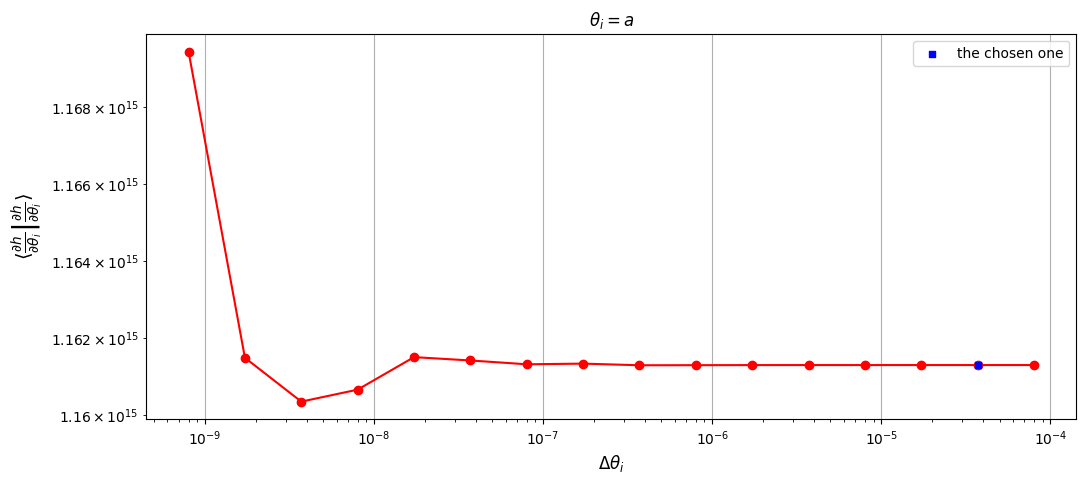

Gamma_ii for p0: 750159941109552.2
Gamma_ii for p0: 750159954803949.1
Gamma_ii for p0: 750159958783277.8
Gamma_ii for p0: 750159982889112.0
Gamma_ii for p0: 750159912028577.8
Gamma_ii for p0: 750160209827497.4
Gamma_ii for p0: 750159866799689.9
Gamma_ii for p0: 750159661549653.5
Gamma_ii for p0: 750158724644650.8
Gamma_ii for p0: 750160658216811.4
Gamma_ii for p0: 750159932860102.6
Gamma_ii for p0: 750149276350554.2
Gamma_ii for p0: 750212154190961.2
Gamma_ii for p0: 749987866427871.6
Gamma_ii for p0: 750174063779264.6
Gamma_ii for p0: 750237036766448.0
[np.float64(1.825530246889674e-08), np.float64(5.304640134957714e-09), np.float64(3.2134257758139176e-08), np.float64(9.446057182445192e-08), np.float64(3.969804259459192e-07), np.float64(4.572729396514042e-07), np.float64(2.7360846883049095e-07), np.float64(1.248942353091755e-06), np.float64(2.5775440759866657e-06), np.float64(9.669360851951445e-07), np.float64(1.4205851934189e-05), np.float64(8.381341205383202e-05), np.float64(0.00029

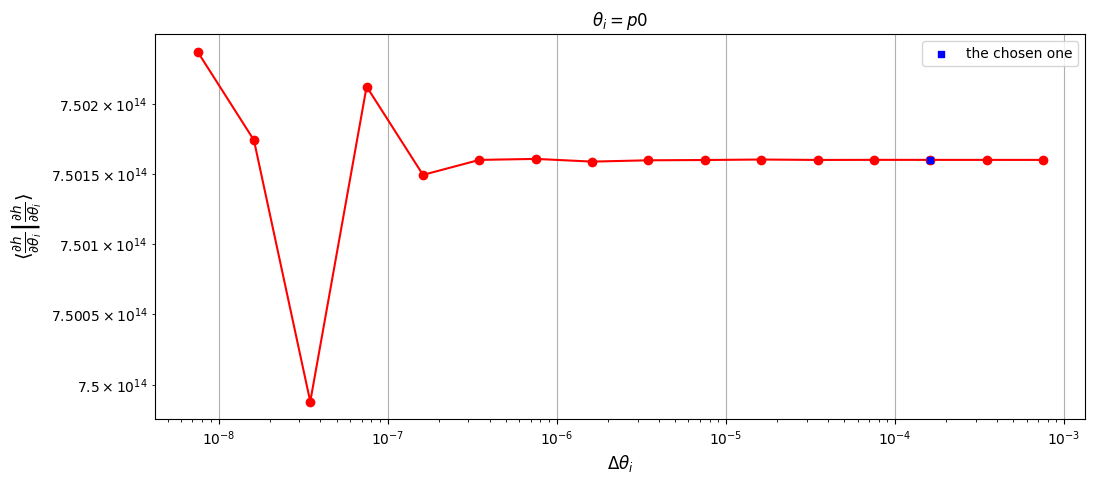

Gamma_ii for e0: 2441707799611295.0
Gamma_ii for e0: 2441707604211719.5
Gamma_ii for e0: 2441707281757416.0
Gamma_ii for e0: 2441707877182427.5
Gamma_ii for e0: 2441708999655059.0
Gamma_ii for e0: 2441702215030674.5
Gamma_ii for e0: 2441703181938516.0
Gamma_ii for e0: 2441743708574075.5
Gamma_ii for e0: 2441687066538553.0
Gamma_ii for e0: 2441679761290424.5
Gamma_ii for e0: 2441588200964405.0
Gamma_ii for e0: 2441274772118267.5
Gamma_ii for e0: 2441249859403875.5
Gamma_ii for e0: 2442791340320824.0
Gamma_ii for e0: 2437802801225679.0
Gamma_ii for e0: 2445967362882043.5
[np.float64(8.002578816683613e-08), np.float64(1.3206099924799907e-07), np.float64(2.438559571618706e-07), np.float64(4.59707783220102e-07), np.float64(2.7786453002889077e-06), np.float64(3.9599728937255713e-07), np.float64(1.659741578003969e-05), np.float64(2.3197909469536707e-05), np.float64(2.9918944508264205e-06), np.float64(3.750031474731673e-05), np.float64(0.0001283873694666255), np.float64(1.0204901516341876e-05)

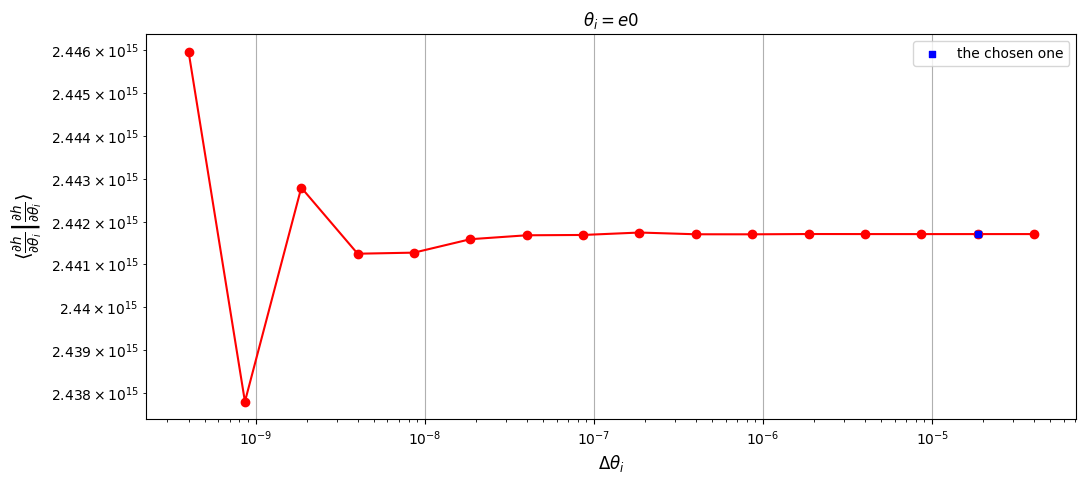

Gamma_ii for qS: 27950.47202025485
Gamma_ii for qS: 27950.472079631563
Gamma_ii for qS: 27950.47207976203
Gamma_ii for qS: 27950.472079762094
Gamma_ii for qS: 27950.472079761967
Gamma_ii for qS: 27950.472079761672
Gamma_ii for qS: 27950.472079764542
Gamma_ii for qS: 27950.472079757656
Gamma_ii for qS: 27950.472079751875
Gamma_ii for qS: 27950.472079737377
Gamma_ii for qS: 27950.47207967546
Gamma_ii for qS: 27950.472079832183
Gamma_ii for qS: 27950.4720794889
Gamma_ii for qS: 27950.472080075506
Gamma_ii for qS: 27950.472079261923
Gamma_ii for qS: 27950.47207920635
[np.float64(2.124354619844138e-09), np.float64(4.667727815387717e-12), np.float64(2.3428448128096235e-15), np.float64(4.555531580463178e-15), np.float64(1.0542801657643465e-14), np.float64(1.0269469762814617e-13), np.float64(2.4638917948051785e-13), np.float64(2.0682113375310295e-13), np.float64(5.186798099474781e-13), np.float64(2.215289928563522e-12), np.float64(5.607208585310305e-12), np.float64(1.2281843299093873e-11), np.

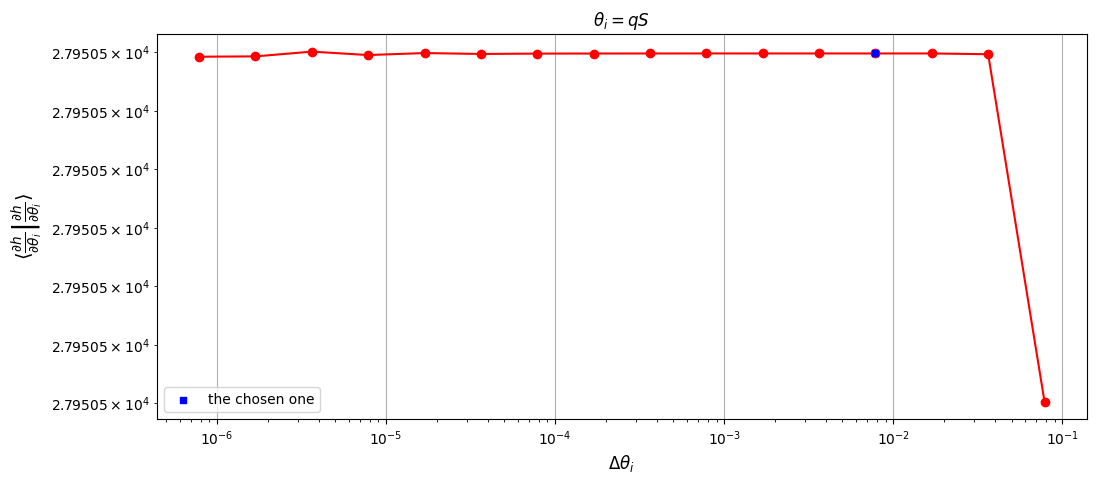

Gamma_ii for phiS: 703219.747677258
Gamma_ii for phiS: 703219.7476554406
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553922
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553922
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553924
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553923
Gamma_ii for phiS: 703219.7476553917
Gamma_ii for phiS: 703219.7476553917
Gamma_ii for phiS: 703219.747655394
Gamma_ii for phiS: 703219.7476554008
Gamma_ii for phiS: 703219.7476554041
Gamma_ii for phiS: 703219.7476553681
[np.float64(3.1025003971128256e-11), np.float64(6.870165224918153e-14), np.float64(1.655461499980278e-16), np.float64(1.6554614999802777e-16), np.float64(1.655461499980278e-16), np.float64(1.6554614999802777e-16), np.float64(1.6554614999802775e-16), np.float64(1.6554614999802777e-16), np.float64(0.0), np.float64(8.277307499901396e-16), np.float64(0.0), np.float64(3.3109229999605475e-15), np.float64(9.601676

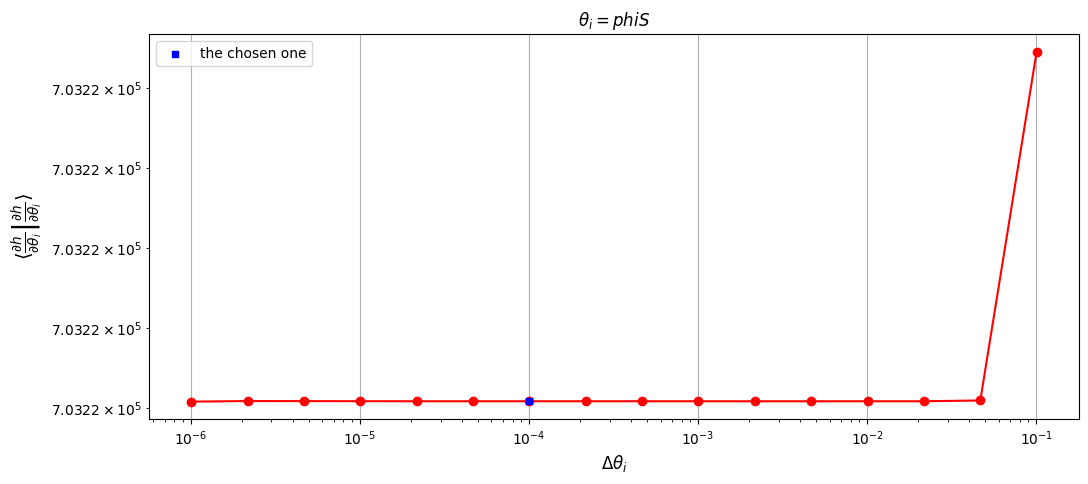

stable deltas: {'m1': 21.545402858495933, 'm2': 0.0002154526406471075, 'a': 3.713469494812866e-05, 'p0': 0.00016157795355954766, 'e0': 1.8565783490706828e-05, 'qS': 0.007829561699999998, 'phiS': 0.00010061406400000001, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 227.79445219039917 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 15.276850461959839 seconds


In [5]:

logm1_0v1_bf = best_fit_0pa_vs_1pa[0]
m1_0v1_bf = np.exp(logm1_0v1_bf)
m2_0v1_bf = best_fit_0pa_vs_1pa[1]
a_0v1_bf = best_fit_0pa_vs_1pa[2]
p0_0v1_bf = best_fit_0pa_vs_1pa[3]
e0_0v1_bf  = best_fit_0pa_vs_1pa[4]
qS_0v1_bf = best_fit_0pa_vs_1pa[5]
phiS_0v1_bf = best_fit_0pa_vs_1pa[6]
Phi_phi0_0v1_bf = best_fit_0pa_vs_1pa[7]
Phi_r0_0v1_bf = best_fit_0pa_vs_1pa[8]

evolve_1PA_0v1_bf = False
deviation_included_0v1_bf = True

pars_list_com = [m1_0v1_bf, m2_0v1_bf, a_0v1_bf, p0_0v1_bf, e0_0v1_bf, xI0, dist, qS_0v1_bf, phiS_0v1_bf, qK,
                  phiK, Phi_phi0_0v1_bf, Phi_theta0, Phi_r0_0v1_bf,chi2,evolve_1PA_0v1_bf,evolve_primary,
                  evolve_2PA,deviation_included_0v1_bf,0,0,0]

add_param_args_0v1_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_0v1_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_0v1_bf,"devCp":0,"devCe":0}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args_0v1_bf = [chi2, evolve_1PA_0v1_bf, evolve_primary, evolve_2PA,deviation_included_0v1_bf,
                   dev_C_p,dev_C_e]


sef_0v1_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_0v1_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_0v1_bf = {
    'm1': m1_0v1_bf,
    'm2': m2_0v1_bf,
    'a': a_0v1_bf,
    'p0': p0_0v1_bf,
    'e0': e0_0v1_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_0v1_bf,
    'phiS': phiS_0v1_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_0v1_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_0v1_bf
}


Fisher_0v1_bf = sef_0v1_bf(wave_params = param_dict_0v1_bf,param_names=param_names, add_param_args=add_param_args_0v1_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )


# Fisher True Point 1PA


waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, True, False, False, True, 0.0, 0.0)
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, True, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 109.44071672839556
calculating stable deltas...
Gamma_ii for m1: 14236.990711096607
Gamma_ii for m1: 14236.990752760064
Gamma_ii for m1: 14236.990957017328
Gamma_ii for m1: 14236.99126097249
Gamma_ii for m1: 14236.99473088564
Gamma_ii for m1: 14236.987114142938
Gamma_ii for m1: 14237.004233878753
Gamma_ii for m1: 14236.97205121362
Gamma_ii for m1: 14237.010898826473
Gamma_ii for m1: 14236.946462798238
Gamma_ii for m1: 14236.794570457829
Gamma_ii for m1: 14237.12776850202
Gamma_ii for m

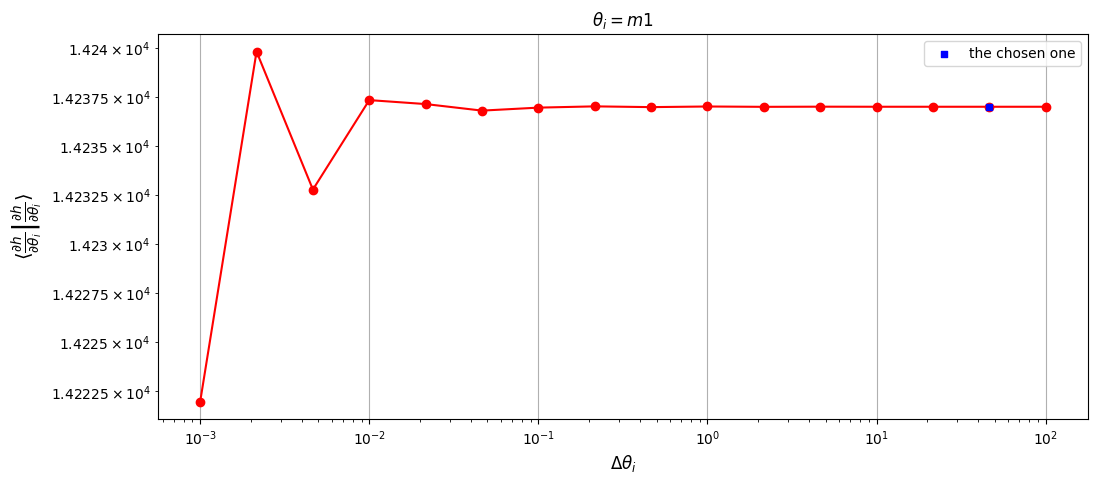

Gamma_ii for m2: 9078357680194.518
Gamma_ii for m2: 9078356868662.393
Gamma_ii for m2: 9078358937950.326
Gamma_ii for m2: 9078358780349.227
Gamma_ii for m2: 9078356317967.371
Gamma_ii for m2: 9078372670280.152
Gamma_ii for m2: 9078366664506.635
Gamma_ii for m2: 9078335839722.607
Gamma_ii for m2: 9078413933866.967
Gamma_ii for m2: 9078272653447.893
Gamma_ii for m2: 9077611503990.287
Gamma_ii for m2: 9078183739296.82
Gamma_ii for m2: 9078685102855.916
Gamma_ii for m2: 9067788922756.338
Gamma_ii for m2: 9085229743337.2
Gamma_ii for m2: 9041078030496.188
[np.float64(8.939196120405116e-08), np.float64(2.279363426514776e-07), np.float64(1.7360087150390457e-08), np.float64(2.712365288631977e-07), np.float64(1.8012383248798024e-06), np.float64(6.615478025423541e-07), np.float64(3.395422307739346e-06), np.float64(8.602179293460643e-06), np.float64(1.5562478069058764e-05), np.float64(7.283297564726627e-05), np.float64(6.30341181635444e-05), np.float64(5.5224248161001566e-05), np.float64(0.001201

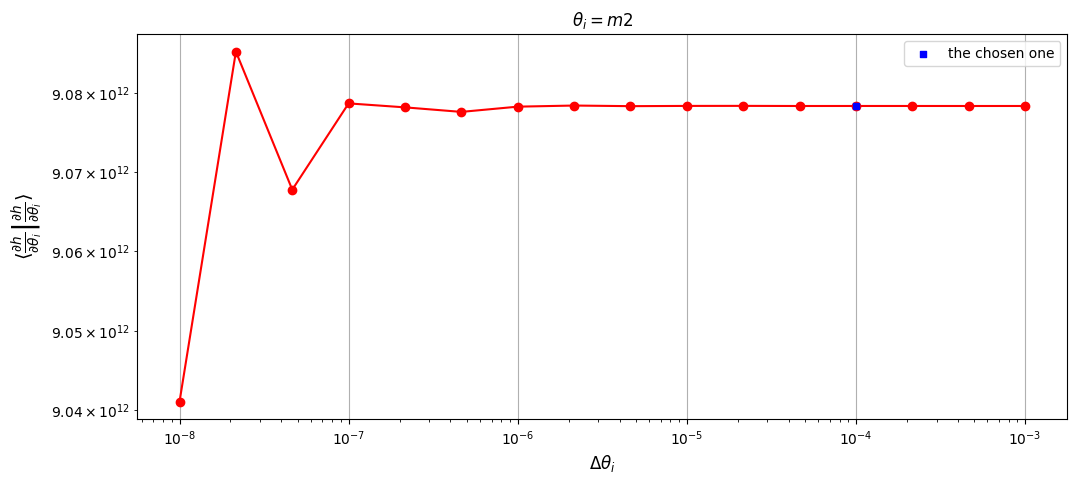

Gamma_ii for a: 1161836006844560.0
Gamma_ii for a: 1161836136828803.0
Gamma_ii for a: 1161836171318705.8
Gamma_ii for a: 1161835694747858.5
Gamma_ii for a: 1161835335970723.0
Gamma_ii for a: 1161837661375132.2
Gamma_ii for a: 1161843111636987.2
Gamma_ii for a: 1161852850348234.0
Gamma_ii for a: 1161842627796845.8
Gamma_ii for a: 1161809875199353.8
Gamma_ii for a: 1161880624480596.2
Gamma_ii for a: 1161785684048678.2
Gamma_ii for a: 1162088028061838.0
Gamma_ii for a: 1161278259224965.5
Gamma_ii for a: 1160508103091713.8
Gamma_ii for a: 1157043938745563.5
[np.float64(1.118782923681373e-07), np.float64(2.9685685126202705e-08), np.float64(4.1018781692141537e-07), np.float64(3.0880205171263686e-07), np.float64(2.001488234163187e-06), np.float64(4.691048042898678e-06), np.float64(8.382052205519042e-06), np.float64(8.798568019177092e-06), np.float64(2.819101316932774e-05), np.float64(6.089203981185895e-05), np.float64(8.171940248664833e-05), np.float64(0.0002601730728299538), np.float64(0.000

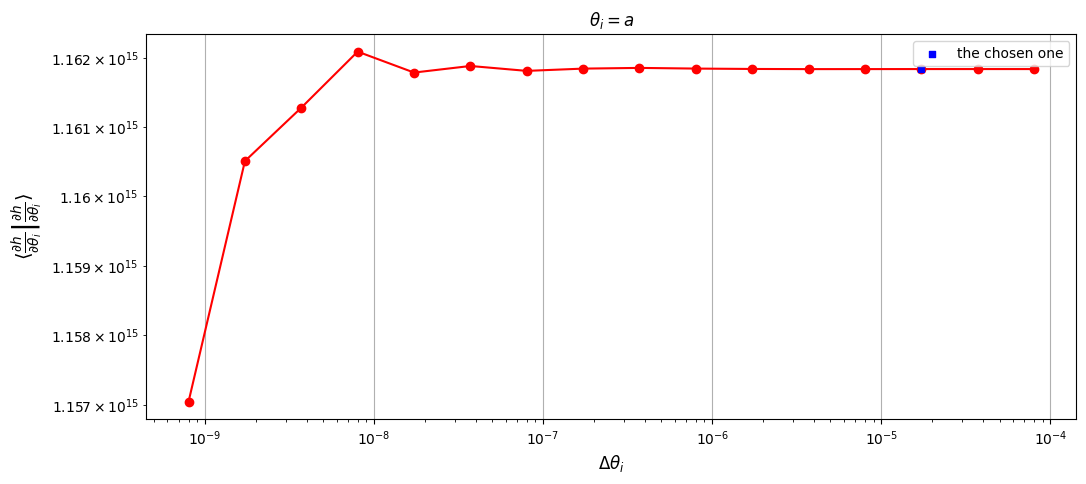

Gamma_ii for p0: 750457632412468.5
Gamma_ii for p0: 750457634319159.8
Gamma_ii for p0: 750457645644818.6
Gamma_ii for p0: 750457640912023.9
Gamma_ii for p0: 750457741310473.9
Gamma_ii for p0: 750457627026059.0
Gamma_ii for p0: 750457564353728.6
Gamma_ii for p0: 750456980379853.9
Gamma_ii for p0: 750458862699351.6
Gamma_ii for p0: 750455575601686.5
Gamma_ii for p0: 750456132285277.9
Gamma_ii for p0: 750494832405821.5
Gamma_ii for p0: 750480045364817.8
Gamma_ii for p0: 750399992966380.9
Gamma_ii for p0: 750263823361726.8
Gamma_ii for p0: 750434142447537.9
[np.float64(2.5407047151033568e-09), np.float64(1.5091669650815016e-08), np.float64(6.306544822767453e-09), np.float64(1.3378294935658994e-07), np.float64(1.5228629939826247e-07), np.float64(8.351215758478165e-08), np.float64(7.781576959340344e-07), np.float64(2.508224755957201e-06), np.float64(4.3801362425611015e-06), np.float64(7.417936471247099e-07), np.float64(5.156613859627264e-05), np.float64(1.9703443276179093e-05), np.float64(0.

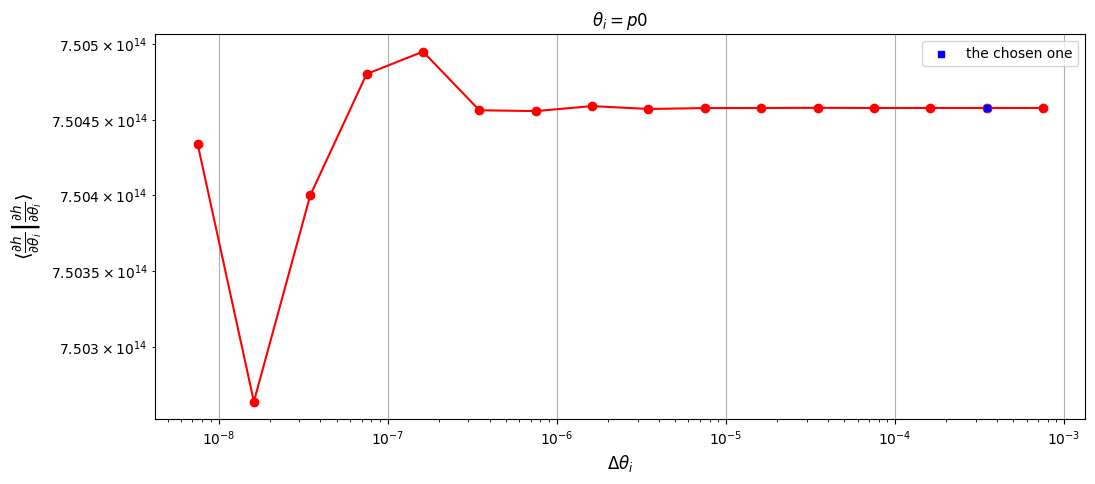

Gamma_ii for e0: 2442983348558318.5
Gamma_ii for e0: 2442983770904515.5
Gamma_ii for e0: 2442983404366852.5
Gamma_ii for e0: 2442983724551142.0
Gamma_ii for e0: 2442981608165004.0
Gamma_ii for e0: 2442984461602823.0
Gamma_ii for e0: 2442981933975976.0
Gamma_ii for e0: 2443008875884170.5
Gamma_ii for e0: 2442915558405983.5
Gamma_ii for e0: 2442997250697221.0
Gamma_ii for e0: 2442689049282073.5
Gamma_ii for e0: 2443101426714409.5
Gamma_ii for e0: 2443606960219312.0
Gamma_ii for e0: 2446237874260539.5
Gamma_ii for e0: 2441489591376541.0
Gamma_ii for e0: 2428731010793397.0
[np.float64(1.728812945996879e-07), np.float64(1.500369025613563e-07), np.float64(1.3106280090295264e-07), np.float64(8.663127593456099e-07), np.float64(1.1680130855715234e-06), np.float64(1.0346481944245341e-06), np.float64(1.1028166315912062e-05), np.float64(3.8199223819217966e-05), np.float64(3.343937092609718e-05), np.float64(0.00012617300398431105), np.float64(0.00016879259609396707), np.float64(0.000206880039684094

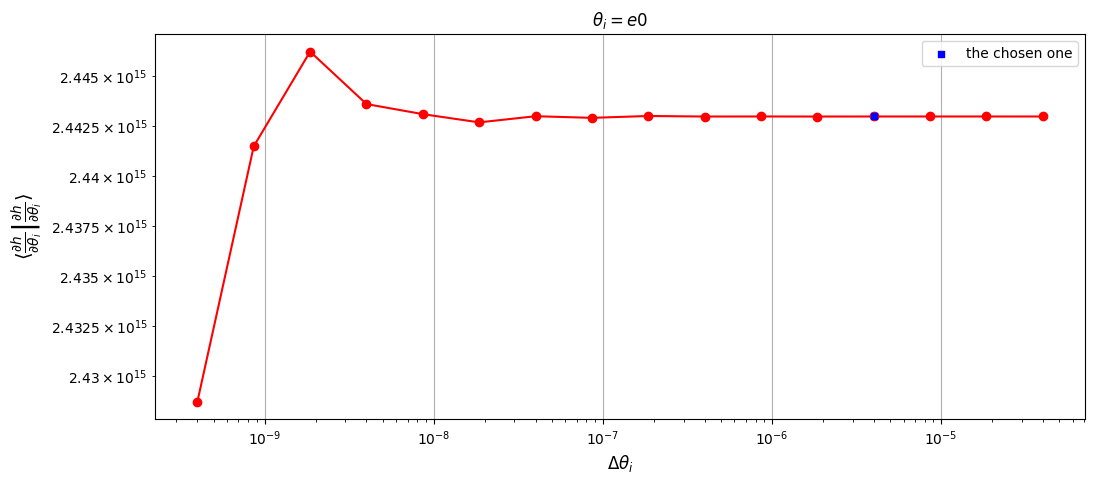

Gamma_ii for qS: 36775.8419672662
Gamma_ii for qS: 36775.842028704996
Gamma_ii for qS: 36775.84202883988
Gamma_ii for qS: 36775.84202884024
Gamma_ii for qS: 36775.84202883953
Gamma_ii for qS: 36775.842028840554
Gamma_ii for qS: 36775.84202883941
Gamma_ii for qS: 36775.842028831445
Gamma_ii for qS: 36775.842028849234
Gamma_ii for qS: 36775.8420288667
Gamma_ii for qS: 36775.84202875972
Gamma_ii for qS: 36775.842028719555
Gamma_ii for qS: 36775.84202887284
Gamma_ii for qS: 36775.84202921009
Gamma_ii for qS: 36775.842030059255
Gamma_ii for qS: 36775.842030194704
[np.float64(1.6706292469564404e-09), np.float64(3.6676713519151285e-12), np.float64(9.892305944317326e-15), np.float64(1.9388919650862336e-14), np.float64(2.7896302762974624e-14), np.float64(3.106184066515711e-14), np.float64(2.1664150018060127e-13), np.float64(4.83733760676999e-13), np.float64(4.748306853268901e-13), np.float64(2.9089314859923222e-12), np.float64(1.0921105762562167e-12), np.float64(4.168024186574968e-12), np.float

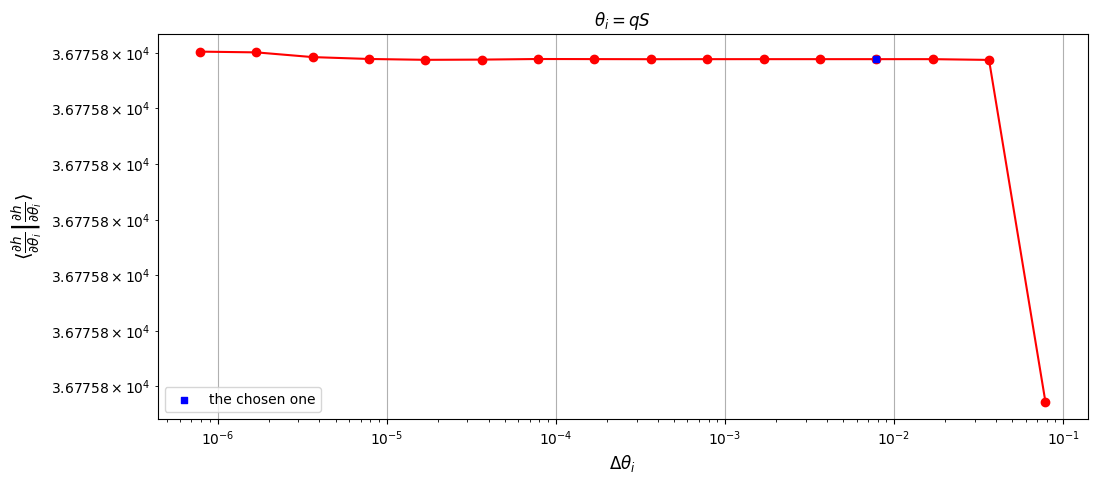

Gamma_ii for phiS: 709755.7602953827
Gamma_ii for phiS: 709755.7602722271
Gamma_ii for phiS: 709755.7602721758
Gamma_ii for phiS: 709755.7602721757
Gamma_ii for phiS: 709755.7602721757
Gamma_ii for phiS: 709755.7602721757
Gamma_ii for phiS: 709755.7602721757
Gamma_ii for phiS: 709755.7602721758
Gamma_ii for phiS: 709755.7602721757
Gamma_ii for phiS: 709755.7602721758
Gamma_ii for phiS: 709755.7602721769
Gamma_ii for phiS: 709755.7602721754
Gamma_ii for phiS: 709755.7602721734
Gamma_ii for phiS: 709755.7602721711
Gamma_ii for phiS: 709755.7602721327
Gamma_ii for phiS: 709755.7602721797
[np.float64(3.262472935634243e-11), np.float64(7.233355444130642e-14), np.float64(1.6402166539978783e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.640216653997878e-16), np.float64(1.6402166539978783e-16), np.float64(1.640216653997878e-16), np.float64(1.6402166539978753e-15), np.float64(2.1322816501972425e-15), np.float64(2.788368311796402e-15), np.float64(3.2804333079957775e-15), n

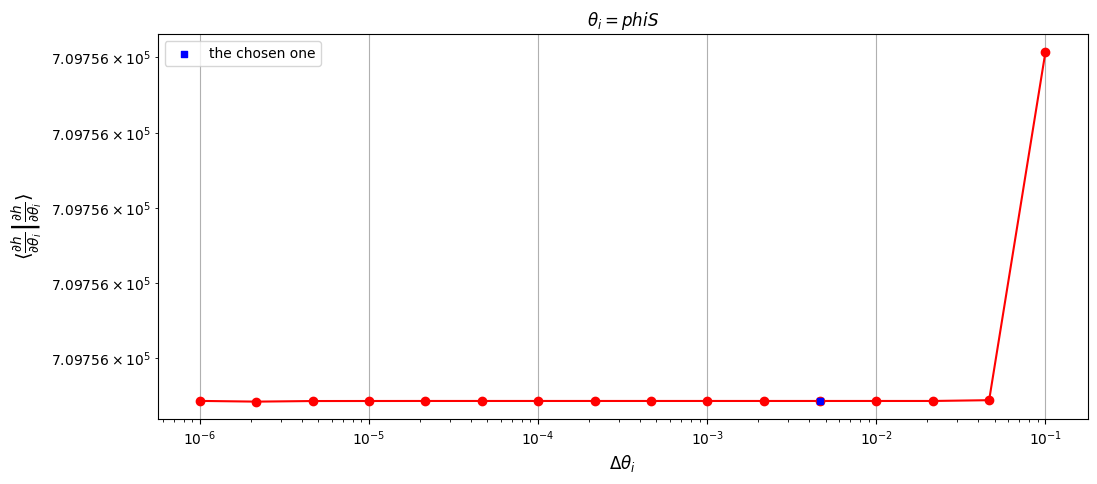

stable deltas: {'m1': 46.4158883361278, 'm2': 0.0001, 'a': 1.7235477520255065e-05, 'p0': 0.0003481191625209583, 'e0': 4.000000000000001e-06, 'qS': 0.007853981633974485, 'phiS': 0.004641588833612782, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 244.03904485702515 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 16.32446050643921 seconds


In [6]:
evolve_1PA = True
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]


sef_true = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_true.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher_true = sef_true(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

In [7]:


# def logmasstransform(Fisher, m1, index_of_m1 = 0):    
#     J = np.eye(len(Fisher))
#     J[index_of_m1,index_of_m1] = m1
    
#     return J.T@Fisher@J
param_true= [m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,0,0] 
param_0v1_bf = best_fit_0pa_vs_1pa.copy()
param_0v1_bf[0] = np.exp(param_0v1_bf[0])
param_bf = best_fit_with_deviation.copy()
param_bf[0] = np.exp(param_bf[0])

Cov_bf = np.linalg.inv(Fisher_bf)
Cov_0v1_bf = np.linalg.inv(Fisher_0v1_bf)
Cov_true = np.linalg.inv(Fisher_true)
     
Cov_0v1_bf

array([[ 3.44073002e+02,  2.08089570e-03,  2.33441384e-04,
        -1.41828681e-03, -7.74597826e-05, -2.42920875e-04,
        -4.21362784e-04, -3.13454013e-01,  8.38503818e-02],
       [ 2.08089570e-03,  1.28897477e-08,  1.41068811e-09,
        -8.52463582e-09, -4.79009975e-10, -1.00493442e-09,
        -6.82236841e-09, -1.75481413e-06,  2.36002969e-07],
       [ 2.33441384e-04,  1.41068811e-09,  1.58570064e-10,
        -9.62842158e-10, -5.23920876e-11, -1.48979040e-10,
        -3.99597153e-10, -2.06513469e-07,  5.47412557e-08],
       [-1.41828681e-03, -8.52463582e-09, -9.62842158e-10,
         5.85628634e-09,  3.17187043e-10,  1.05194119e-09,
         1.25681530e-09,  1.30198584e-06, -3.87053922e-07],
       [-7.74597826e-05, -4.79009975e-10, -5.23920876e-11,
         3.17187043e-10,  1.78985031e-11,  5.04925196e-11,
         1.52087217e-10,  7.09970290e-08, -1.09302220e-08],
       [-2.42920876e-04, -1.00493442e-09, -1.48979040e-10,
         1.05194120e-09,  5.04925197e-11,  2.884719

18.542828595381806 138.34688163839027 18.5492048921766


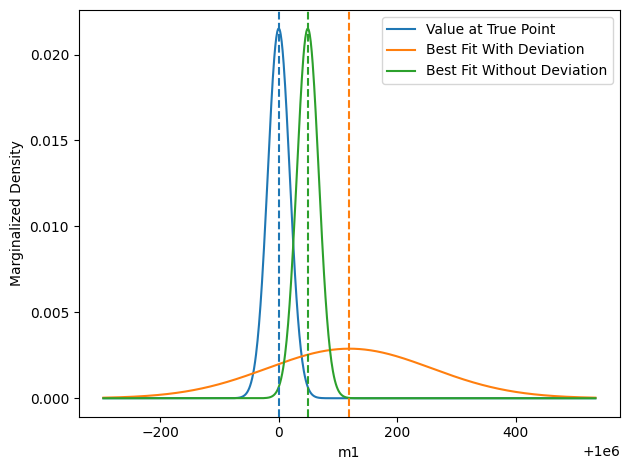

0.00011348705156358101 0.0017561826375710138 0.00011353302451420275


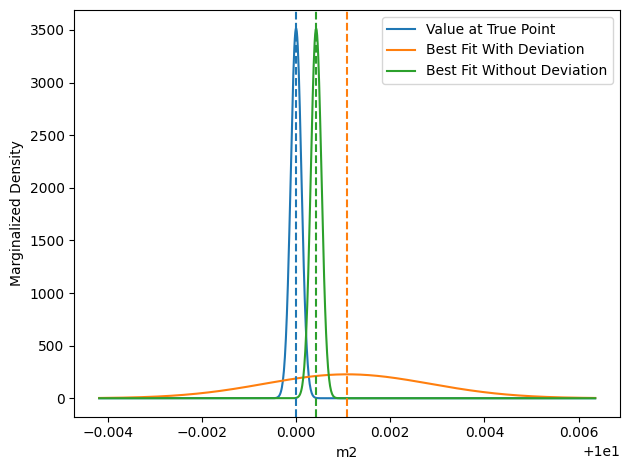

1.2589573319103476e-05 7.817059967291188e-05 1.2592460602737526e-05


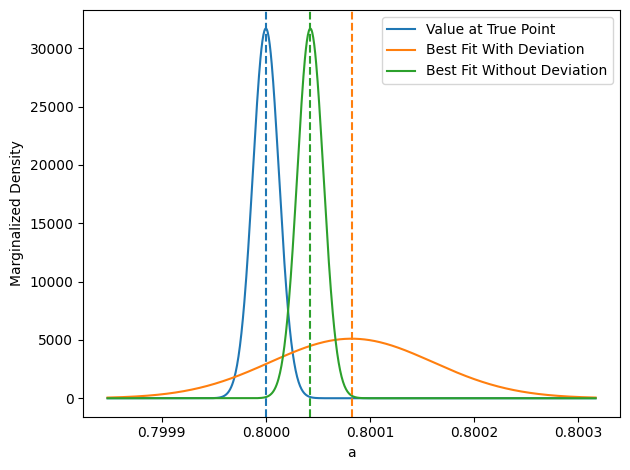

7.65071201167015e-05 0.00045719908643752623 7.65263767866716e-05


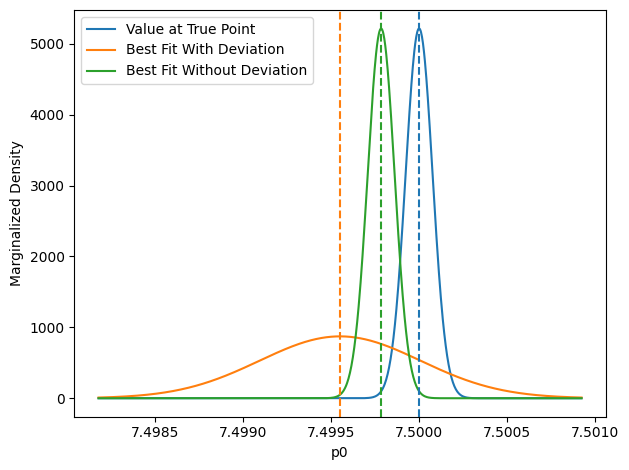

4.229141426609795e-06 4.800139394967455e-05 4.230662250425068e-06


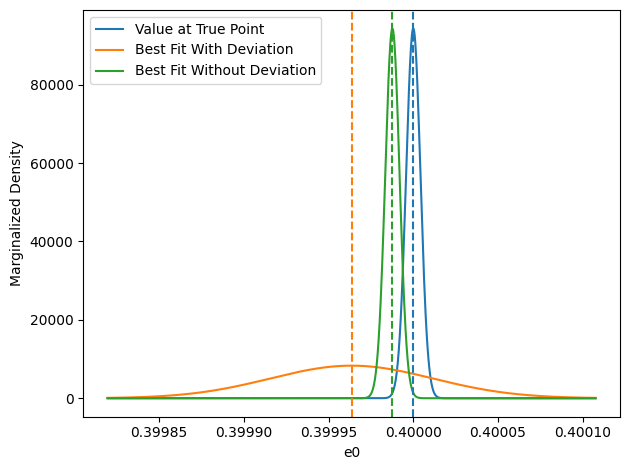

0.017007019788809703 0.01701692994638072 0.01698446055797694


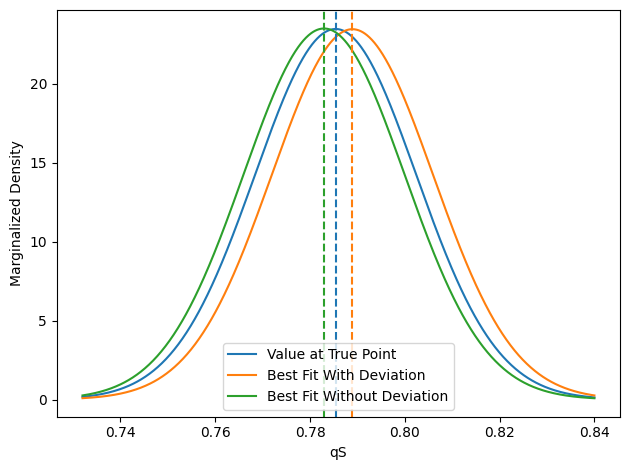

0.021509224292695733 0.021493637706741932 0.02152448630769394


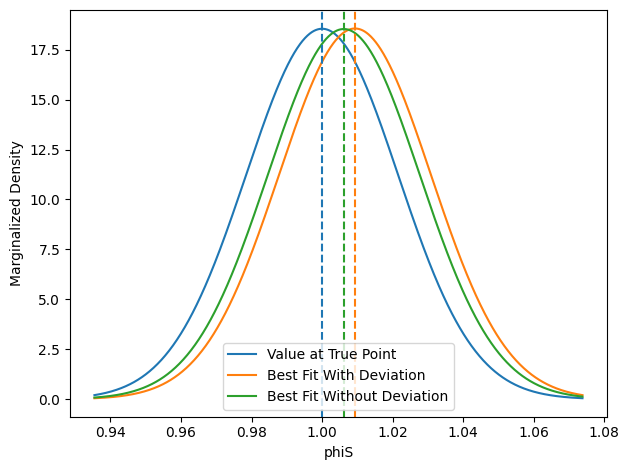

0.08751357647259989 0.09330731979500193 0.08693932438590544


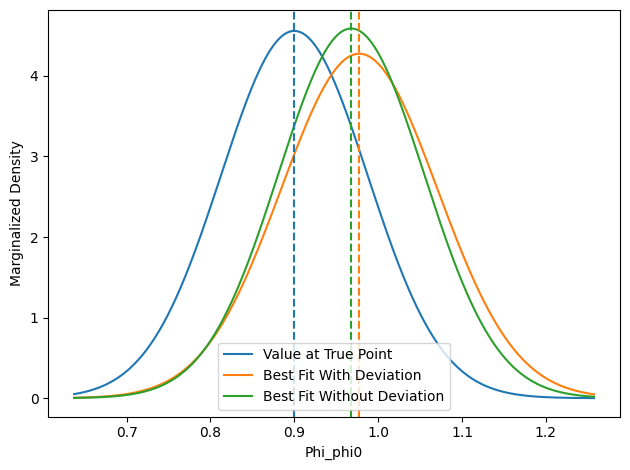

In [8]:
# FOR FIRST EIGHT PARAMETERS ONLY (DOES NOT INCLUDE DEVIATION PARAMETERS)
from scipy.stats import norm

npar = 8
for i in range(npar):

    mu1, sigma1 = param_true[i], np.sqrt(Cov_true[i, i])
    mu2, sigma2 = param_bf[i], np.sqrt(Cov_bf[i, i])
    mu3, sigma3 = param_0v1_bf[i], np.sqrt(Cov_0v1_bf[i, i])

    print(sigma1,sigma2,sigma3)

    # x-range covering all three posteriors
    xmin = min(mu1 - 3*sigma1, mu2 - 3*sigma2, mu3 - 3*sigma3)
    xmax = max(mu1 + 3*sigma1, mu2 + 3*sigma2, mu3 + 3*sigma3)
    x = np.linspace(xmin, xmax, 1000)

    plt.figure()

    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
    line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())
    plt.axvline(mu3, linestyle="--", color=line3.get_color())

    plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

9


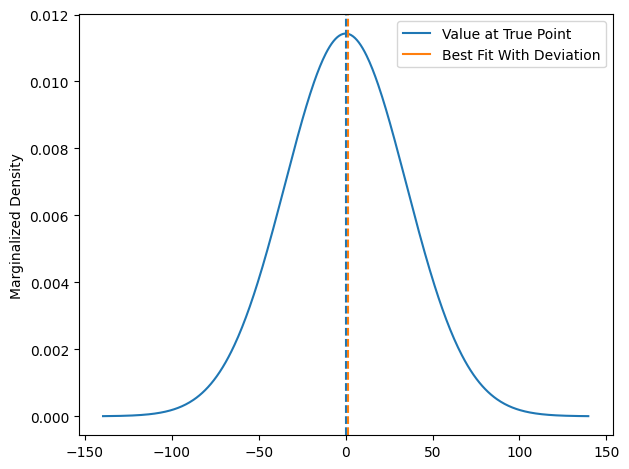

10


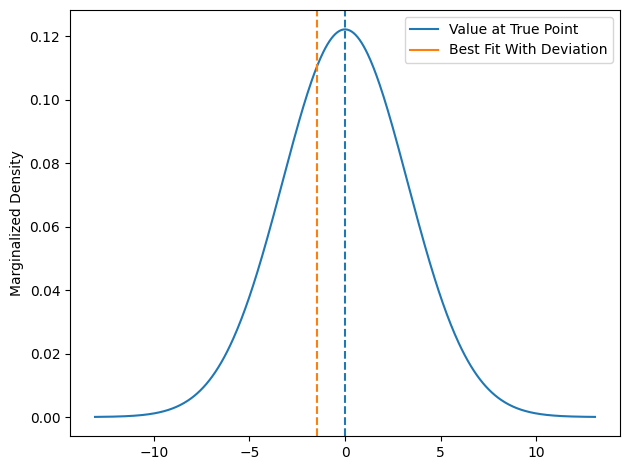

In [17]:
npar = 8
for i in range(npar+1,11):
    print(i)

    mu1, sigma1 = param_true[i], np.sqrt(Cov_bf[i, i])
    mu2, sigma2 = param_bf[i], 0

    # x-range covering all three posteriors
    xmin = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    xmax = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(xmin, xmax, 500)

    plt.figure()


    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())


    #plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
Cov_bf[9, 9]

np.float64(1217.9453702429926)